# 4장. 신경망 학습

### dataset/mnist.py

In [23]:
import urllib.request
import os
import os.path
import pickle
import numpy as np
import tensorflow as tf

mnist = tf.keras.datasets.mnist
save_file = os.getcwd() + "/mnist.pkl"

def _convert_numpy():
    dataset = {}

    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()

    # 이미지 데이터 평탄화
    dataset['train_img'] = train_images.reshape(train_images.shape[0], -1)
    dataset['train_label'] = train_labels
    dataset['test_img'] = test_images.reshape(test_images.shape[0], -1)
    dataset['test_label'] = test_labels

    return dataset

def init_mnist():
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")

def _change_one_hot_label(X):
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1

    return T

def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """MNIST 데이터셋 읽기

    Parameters
    ----------
    normalize : 이미지의 픽셀 값을 0.0~1.0 사이의 값으로 정규화할지 정한다.
    one_hot_label :
        one_hot_label이 True면、레이블을 원-핫(one-hot) 배열로 돌려준다.
        one-hot 배열은 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 한 원소만 1인 배열이다.
    flatten : 입력 이미지를 1차원 배열로 만들지를 정한다.

    Returns
    -------
    (훈련 이미지, 훈련 레이블), (시험 이미지, 시험 레이블)
    """
    if not os.path.exists(save_file):
        init_mnist()

    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)

    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0

    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])

    if not flatten:
         for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label'])

### common/functions.py

In [24]:
import numpy as np

def softmax(x):
    if x.ndim == 2:
    # 2차원 데이터 처리시. 즉 (Batch, Class) = (100, 10)
        x = x.T # 전치행렬 -> (10,100)
        x = x - np.max(x, axis=0) # 열방향에서 제일 큰 값 찾기 -> 결과는 100개의 최댓값이 담긴(100, ) : 즉 이미지 한장마다 제일 큰 값을 뺌
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

## 4.2 손실 함수

### 4.2.1 오차제곱합

In [25]:
def sum_squares_error(y, t):
    return 0.5 * np.sum((y-t)**2)

In [26]:
# 정답은 '2'
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# 예1: '2'일 확률이 가장 높다고 추정함(0.6)
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

sum_squares_error(np.array(y), np.array(t))

0.09750000000000003

In [27]:
# 예2: '7'일 확률이 가장 높다고 추정함(0.6)
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
sum_squares_error(np.array(y), np.array(t))

0.5975

### 4.2.2 교차 엔트로피 오차

In [28]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [29]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

cross_entropy_error(np.array(y), np.array(t))

0.510825457099338

In [30]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
cross_entropy_error(np.array(y), np.array(t))

2.302584092994546

### 4.2.3 미니배치 학습

In [31]:
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize = True, one_hot_label = True)

print(x_train.shape)  # (60000, 784)
print(t_train.shape)  # (60000, 10)

(60000, 784)
(60000, 10)


In [32]:
train_size = x_train.shape[0] # 60,000
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size) #0부터 59,999 사이의 숫자 중 무작위로 10개를 골라낸다.
x_batch = x_train[batch_mask] # x_batch = (10, 784)
t_batch = t_train[batch_mask] # t_batch = (10, 10)

In [33]:
np.random.choice(60000, 10)

array([ 1740, 54705, 10524, 11730, 45802, 47998,  8327, 51753, 19388,
       10712])

### 4.2.4 (배치용) 교차 엔트로피 오차 구현하기

In [34]:
# 원핫 인코딩 용 -> t가 원핫 배열일때 사용한다.
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        # 1장짜리 배치로 취급
    batch_size = y.shape[0] # (N,C) (데이터의 개수, 클래스 개수) (100, 10)
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

$$E = -\frac{1}{N} \sum_{n} \sum_{k} t_{nk} \ln y_{nk}$$

만약 데이터 3개를 한꺼번에 처리하고, 정답(t)이 [2, 0, 1]이라고 가정
- 모델의 예측값 (y):$$y = \begin{bmatrix} 0.1 & 0.2 & \mathbf{0.7} \\ \mathbf{0.9} & 0.05 & 0.05 \\ 0.1 & \mathbf{0.8} & 0.1 \end{bmatrix}$$
- np.arange(3): [0, 1, 2]
- y[np.arange(3), t]:
    - y[0, 2] $\rightarrow$ 0.7 (첫 번째 데이터의 정답인 2번 클래스 확률)
    - y[1, 0] $\rightarrow$ 0.9 (두 번째 데이터의 정답인 0번 클래스 확률)
    - y[2, 1] $\rightarrow$ 0.8 (세 번째 데이터의 정답인 1번 클래스 확률)

In [35]:
# 숫자 레이블(Integer Label)용
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        # 1장짜리 배치로 취급
    batch_size = y.shape[0] # (N,C) (데이터의 개수, 클래스 개수) (100, 10)
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

## 4.3 수치 미분

### 4.3.1 미분

In [36]:
# 나쁜 구현 예
def numerical_diff(f, x):
    h = 1e-50
    return (f(x + h) - f(x)) / h

In [37]:
np.float32(1e-50)

0.0

***ch04/gradient_1d.py***

In [38]:
def numerical_diff(f, x):
    h = 1e-4  # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)

### 4.3.2 수치 미분의 예

***ch04/gradient_1d.py***

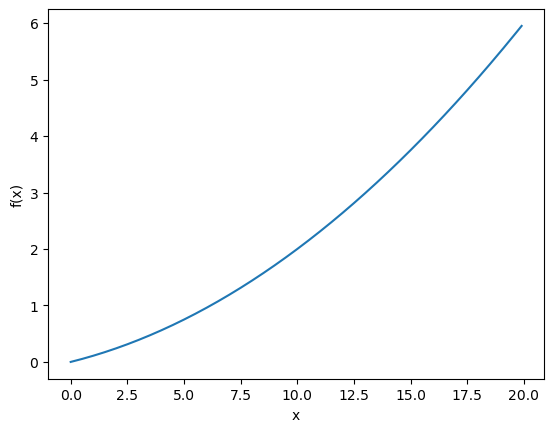

In [39]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

import numpy as np
import matplotlib.pylab as plt

x = np.arange(0.0, 20.0, 0.1)  # 0에서 20까지 0.1 간격의 배열 x를 만든다(20은 미포함).
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [40]:
numerical_diff(function_1, 5)

0.1999999999990898

In [41]:
numerical_diff(function_1, 10)

0.2999999999986347

***ch04/gradient_1d.py***

[그림 4-7]의 왼쪽 그래프

0.1999999999990898


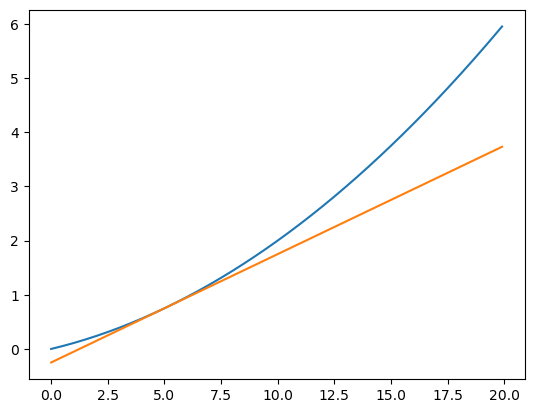

In [42]:
#접선 추가
def tangent_line(f, x):
    d = numerical_diff(f, x)
    print(d)
    y = f(x) - d*x # 접선의 방정식인 y = mx + b 에서 y 절편을 구하는 과정 b = y - mx 식에 따라 (x,f(x)) 를 대입하였다. 
    return lambda t: d*t + y # 구한 기울기 d 와 절편 y 를 사용해서 f(t) = dt + y 를 만들어 반환

tf = tangent_line(function_1, 5)  # x = 5
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()

***ch04/gradient_1d.py***

[그림 4-7]의 오른쪽 그래프

0.2999999999986347


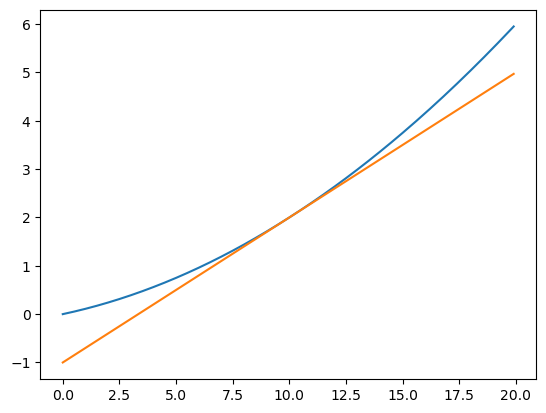

In [43]:
tf = tangent_line(function_1, 10)  # x = 10
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()

### 4.3.3 편미분

In [44]:
def function_2(x):
    return x[0]**2 + x[1]**2
    # 또는 return np.sum(x**2)

In [45]:
def function_tmp1(x0):
    return x0*x0 + 4.0**2.0

numerical_diff(function_tmp1, 3.0)

6.00000000000378

In [46]:
def function_tmp2(x1):
    return 3.0**2.0 + x1*x1

numerical_diff(function_tmp2, 4.0)

7.999999999999119

## 4.4 기울기

In [47]:
def numerical_gradient(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)  # x와 형상이 같은 배열을 생성

    # x = [a,b,c]
    # grad = [0,0,0]
    # idx = [0,1,2]
    # tmp_val = a  
    # x = [a+10^-4, b, c]
    # fxh1 = f(a+10^-4, b, c)
    # x = [a-10^-4, b, c]
    # fxh2 = f(a-10^-4, b, c)
    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val  # 값 복원

    return grad

In [48]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [49]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [50]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

***ch04/gradient_2d.py***

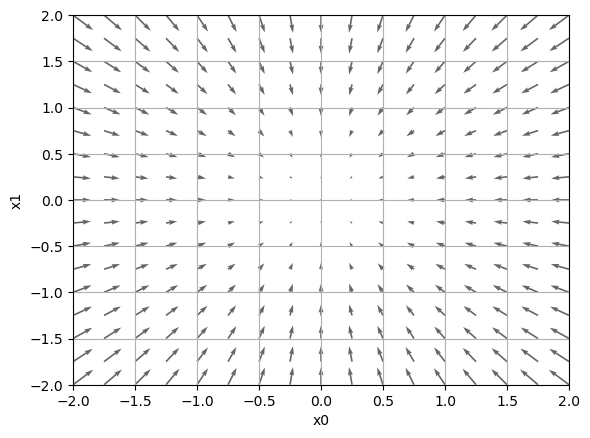

In [51]:
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D

# x = [a,b,c]
# grad = [0,0,0]
# idx = [0,1,2]
# tmp_val = a  
# x = [a+10^-4, b, c]
# fxh1 = f(a+10^-4, b, c)
# x = [a-10^-4, b, c]
# fxh2 = f(a-10^-4, b, c)
def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원

    return grad

def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        # idx 는 행, x 는 그 행 벡터
        return grad

def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)

x0 = np.arange(-2, 2.5, 0.25)
x1 = np.arange(-2, 2.5, 0.25)
X, Y = np.meshgrid(x0, x1)

X = X.flatten()
Y = Y.flatten()

grad = numerical_gradient(function_2, np.array([X, Y]))

# np.array([X, Y]) 의 모습
#[
#  [ -2.0, -1.75, ... 2.25 ],  # 1행 (X의 데이터들)
#  [ -2.0, -2.0, ... 2.25 ]    # 2행 (Y의 데이터들)
#]
plt.figure()
plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy",color="#666666")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid()
plt.draw()
plt.show()

### 4.4.1 경사법(경사 하강법)

1. 매개변수 (Parameters)
    - f: 우리가 최소로 만들고 싶은 목적 함수. (예: $x_0^2 + x_1^2$)
    - init_x: 탐색을 시작할 초기 지점 (산맥의 어디서부터 내려갈 것인지 정하는 것과 같다.)
    - lr (Learning Rate, 학습률): 한 걸음의 크기.
    - step_num: 총 몇 걸음을 걸을 것인지 정하는 반복 횟수

In [52]:
def gradient_descent(f, init_x, lr= 0.01, step_num = 100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

In [53]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x = init_x, lr = 0.1, step_num = 100)

array([-6.11110793e-10,  8.14814391e-10])

***ch04/gradient_method.py***

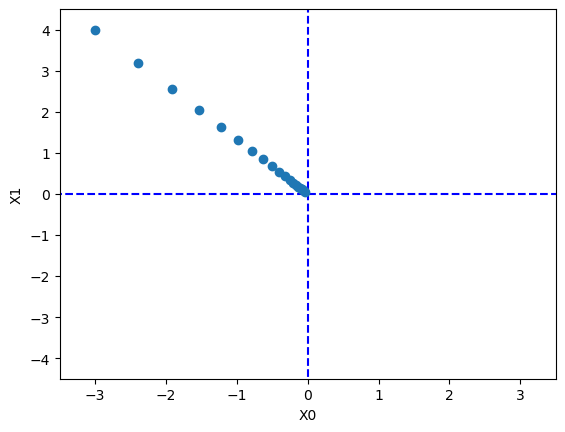

In [54]:
import numpy as np
import matplotlib.pylab as plt
#from gradient_2d import numerical_gradient

def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)


def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()

In [55]:
# 학습률이 너무 큰 예: lr = 10.0
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x = init_x, lr = 10.0, step_num = 100)

(array([-2.58983747e+13, -1.29524862e+12]),
 array([[-3.00000000e+00,  4.00000000e+00],
        [ 5.70000000e+01, -7.60000000e+01],
        [-1.08300000e+03,  1.44400000e+03],
        [ 2.05770000e+04, -2.74360000e+04],
        [-3.90963008e+05,  5.21284002e+05],
        [ 7.42829664e+06, -9.90439654e+06],
        [-1.41137328e+08,  1.88183103e+08],
        [ 2.68126267e+09, -3.57501690e+09],
        [-5.09763373e+10,  6.79001831e+10],
        [ 9.45170863e+11, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.29524862e+12],
        [-2.58983747e+13, -1.295

In [56]:
# 학습률이 너무 작은 예: lr = 1e-10
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x = init_x, lr = 1e-10, step_num = 100)

(array([-2.99999994,  3.99999992]),
 array([[-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  4.        ],
        [-3.        ,  3.99999999],
        [-3.        ,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999999],
        [-2.99999999,  3.99999998],
        [-2.99999999,  3.99999998],
        [-2.99999999,  3.99999998],
        [-2.99999999,  3.99999998],
        [-2.99999999,  3.99999998],
        [-2.99999999,  3.99999998],
        [-2.99999998,  3.99999998],
        [-2.99999998,  3.999

전체 데이터 Loss vs 배치 데이터 Loss
- 전체 데이터 Loss (Global Loss): 모든 데이터 $N$개에 대한 오차의 평균이다.
$$L(\theta) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(x_i, y_i; \theta)$$
- 배치 데이터 Loss (Batch Loss): 매 스텝마다 무작위로 뽑힌 일부 데이터 $n$개에 대한 오차의 평균이다.
$$L_{batch}(\theta) = \frac{1}{n} \sum_{i \in batch} \mathcal{L}(x_i, y_i; \theta)$$

$$W_{new} = W_{old} - \eta (\text{Learning Rate}) \times \nabla L (\text{Gradient})$$

### 4.4.2 신경망에서의 기울기

***ch04/gradient_simplenet.py***

- np.random.randn(2, 3)은 평균 0, 표준편차 1인 가중치를 $2 \times 3$ 행렬 모양으로 랜덤하게 생성

In [57]:
import numpy as np
#from common.functions import softmax, cross_entropy_error
#from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)  # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

In [58]:
net = simpleNet()
print(net.W)  # 가중치 매개변수

[[ 0.45450508  1.06313828  0.97976428]
 [-0.29090033 -1.9967121   0.09445212]]


In [59]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[ 0.01089275 -1.15915792  0.67286547]


In [60]:
np.argmax(p)  # 최댓값의 인덱스

2

In [61]:
t = np.array([0, 0, 1])  # 정답 레이블
net.loss(x, t)

4.705057625850108

- $z = x \cdot W$ 
- $y = \text{softmax}(z)$
- $\text{Loss} = \text{CEE}(y, t)$

In [62]:
import numpy as np
#from common.functions import softmax, cross_entropy_error
#from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)  # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

6개의 서로 다른 변수($w_{11}, w_{12}, \dots, w_{23}$)
$$W = \begin{pmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \end{pmatrix}$$
기울기 행렬 $dW$
$$\nabla_W L = dW = \begin{pmatrix} \frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{13}} \\ \frac{\partial L}{\partial w_{21}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{23}} \end{pmatrix}$$

In [63]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
# net.w
# [[-2.17611155 -0.3280992  -0.4771866 ]
# [ 1.30974094  1.14783446  0.75180036]]
print(dW)

[[-0.64597719 -0.42805784  1.07403503]
 [-0.96896578 -0.64208676  1.61105254]]


In [64]:
f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)
print(dW)

[[-0.64597719 -0.42805784  1.07403503]
 [-0.96896578 -0.64208676  1.61105254]]


## 4.5 학습 알고리즘 구현하기

### 4.5.1 2층 신경망 클래스 구현하기

$$E = -\frac{1}{N} \sum_{n=1}^{N} \log(y_{n, t_n})$$

만약 데이터 3개를 한꺼번에 처리하고, 정답(t)이 [2, 0, 1]이라고 가정해 보자
- 모델의 예측값 (y):$$y = \begin{bmatrix} 0.1 & 0.2 & \mathbf{0.7} \\ \mathbf{0.9} & 0.05 & 0.05 \\ 0.1 & \mathbf{0.8} & 0.1 \end{bmatrix}$$
- np.arange(3): [0, 1, 2]
- y[np.arange(3), t]:
    - y[0, 2] $\rightarrow$ 0.7 (첫 번째 데이터의 정답인 2번 클래스 확률)
    - y[1, 0] $\rightarrow$ 0.9 (두 번째 데이터의 정답인 0번 클래스 확률)
    - y[2, 1] $\rightarrow$ 0.8 (세 번째 데이터의 정답인 1번 클래스 확률)

In [65]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
    # 행렬 전체 원소의 개수가 같다면
    if t.size == y.size:
        # 각 행에서 가장 큰 값(=정답)의 인덱스를 t 에 저장
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [66]:
y = np.array([
    [0.1, 0.2, 0.7],
    [0.9, 0.05, 0.05],
    [0.1, 0.8, 0.1]
])
t = np.array([2, 0, 1])
print(y)
print(t)
print(y.size)
print(t.size)

[[0.1  0.2  0.7 ]
 [0.9  0.05 0.05]
 [0.1  0.8  0.1 ]]
[2 0 1]
9
3


***ch04/two_layer_net.py***

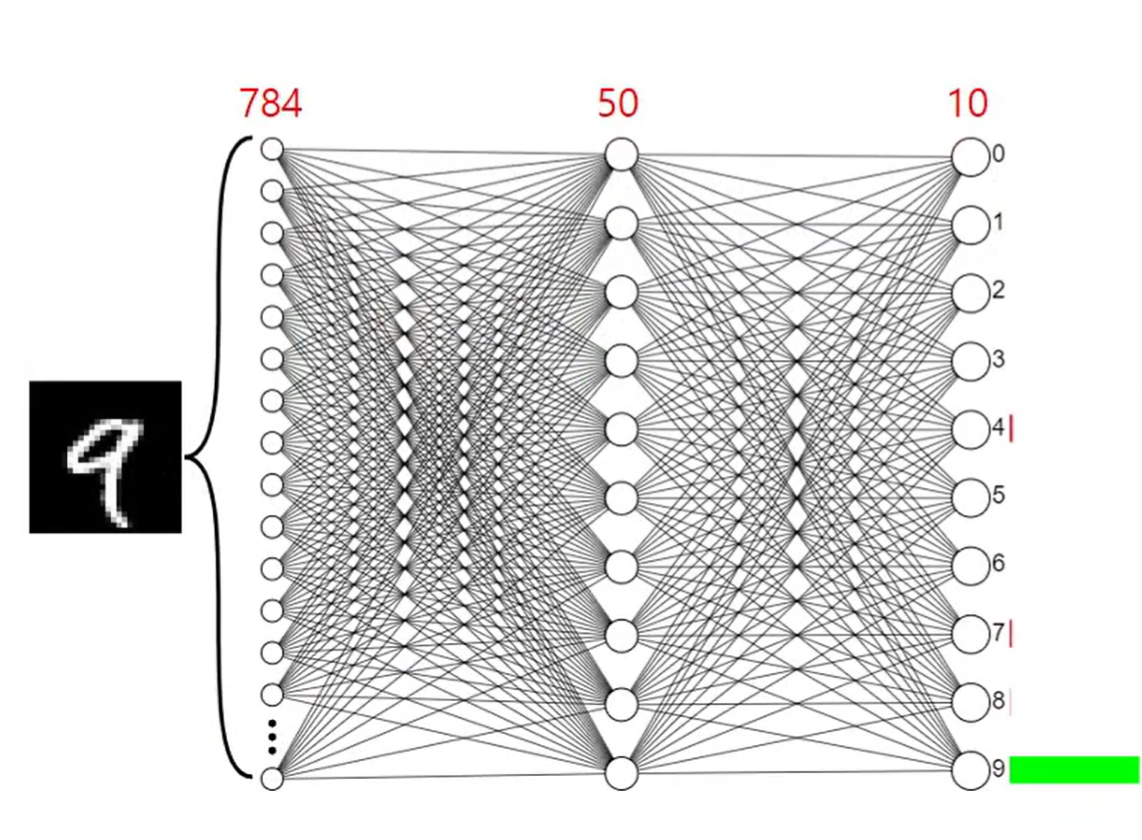

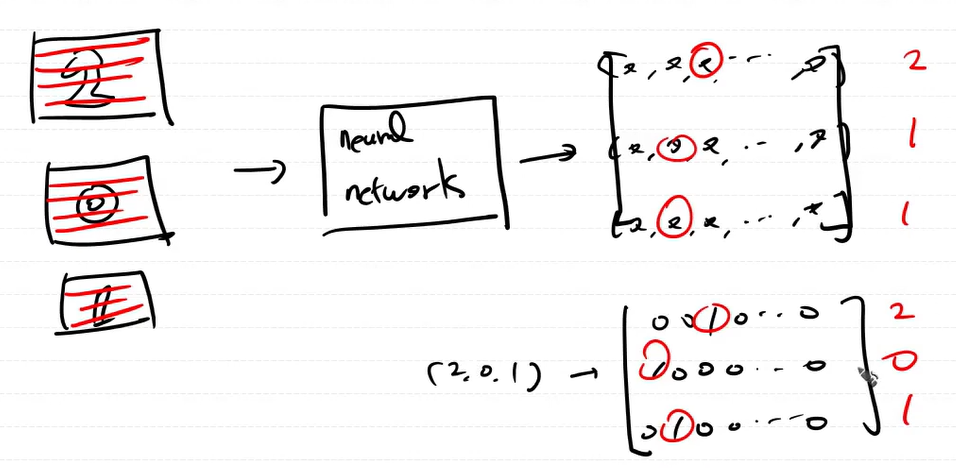

1층 가중치와 편향의 기울기
- $W_1$이 $I \times H$ 크기라면, 그 기울기 $\frac{\partial L}{\partial W_1}$도 똑같은 크기의 행렬이다.

$$\frac{\partial L}{\partial W_1} = \begin{pmatrix} \frac{\partial L}{\partial w^{(1)}_{11}} & \dots & \frac{\partial L}{\partial w^{(1)}_{1H}} \\ \vdots & \ddots & \vdots \\ \frac{\partial L}{\partial w^{(1)}_{I1}} & \dots & \frac{\partial L}{\partial w^{(1)}_{IH}} \end{pmatrix}, \quad \frac{\partial L}{\partial b_1} = \left( \frac{\partial L}{\partial b^{(1)}_1}, \dots, \frac{\partial L}{\partial b^{(1)}_H} \right)$$

2층 가중치와 편향의 기울기
- 마찬가지로 $W_2$가 $H \times O$ 크기라면, 그 기울기 $\frac{\partial L}{\partial W_2}$도 같은 크기의 행렬이 된다.
$$\frac{\partial L}{\partial W_2} = \begin{pmatrix} \frac{\partial L}{\partial w^{(2)}_{11}} & \dots & \frac{\partial L}{\partial w^{(2)}_{1O}} \\ \vdots & \ddots & \vdots \\ \frac{\partial L}{\partial w^{(2)}_{H1}} & \dots & \frac{\partial L}{\partial w^{(2)}_{HO}} \end{pmatrix}, \quad \frac{\partial L}{\partial b_2} = \left( \frac{\partial L}{\partial b^{(2)}_1}, \dots, \frac{\partial L}{\partial b^{(2)}_O} \right)$$

numerical_gradient(loss_W, self.params['W1'])를 호출하는 것은 행렬 $W_1$의 모든 원소를 하나하나 미분해서 $dW_1$ 행렬을 만들라는 의미이다.

- 함수 정의: loss_W(W) 는 $W$를 입력하면 최종 오차 $L$을 뱉는 함수이다.
- 원소별 접근: $$\text{gradient}_{ij} \approx \frac{L(w_{ij} + h) - L(w_{ij} - h)}{2h}$$
- 행렬 조립: 모든 $i, j$에 대해 반복한 다음, 그 결과값들을 원래 행렬과 똑같은 위치에 채워 넣어서 기울기 행렬 $dW$을 만든다.

In [71]:
#from common.functions import *
#from common.gradient import numerical_gradient

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size,
                weight_init_std = 0.01):
        # 가중치 초기화
        # W1 : 입력 -> 은닉 (784, 100)
        # b1 : 은닉층 편향 (100,)
        # W2 : 은닉 -> 출력 (100, 10)
        # b2 : 출력층 편향 (10,)
        self.params = {} # 딕셔너리 형태로 저장  
        self.params['W1'] = weight_init_std * \
                            np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis = 1)
        t = np.argmax(t, axis = 1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # x : 입력 데이터, t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

    # 성능 개선판
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

In [73]:
net = TwoLayerNet(input_size = 784, hidden_size = 100, output_size = 10)
net.params['W1'].shape  # (784, 100)

(784, 100)

In [74]:
net.params['b1'].shape  # (100,)

(100,)

In [75]:
net.params['W2'].shape  # (100, 10)

(100, 10)

In [76]:
net.params['b2'].shape  # (10,)

(10,)

In [77]:
x = np.random.rand(100, 784)  # 더미 입력 데이터(100장 분량)
y = net.predict(x)

In [78]:
x = np.random.rand(100, 784)  # 더미 입력 데이터(100장 분량)
t = np.random.rand(100, 10)   # 더미 정답 레이블(100장 분량)

grads = net.numerical_gradient(x, t)  # 기울기 계산

grads['W1'].shape  # (784, 100)

(784, 100)

In [80]:
grads['b1'].shape  # (100,)

(100,)

In [81]:
grads['W2'].shape  # (100, 10)

(100, 10)

In [82]:
grads['b2'].shape  # (10,)

(10,)

### 4.5.2 미니배치 학습 구현하기

***ch04/train_neuralnet_1.py***

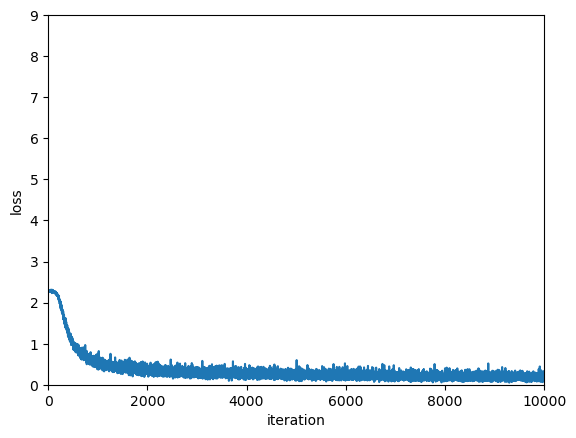

In [83]:
import numpy as np
#from dataset.mnist import load_mnist
#from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize = True, one_hot_label = True)

train_loss_list = []

# 하이퍼파라미터
iters_num = 10000  # 반복 횟수
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1
network = TwoLayerNet(input_size = 784, hidden_size = 50, output_size = 10)

for i in range(iters_num):
    # 6만 개 중 랜덤하게 100개의 '인덱스 번호' 를 뽑는다.
    batch_mask = np.random.choice(train_size, batch_size)
    # 뽑힌 번호표를 가지고 실제 이미지(x)와 정답(t)을 가져온다.
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)  # 성능 개선판!

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

# 그래프 그리기
x = np.arange(len(train_loss_list))
plt.plot(x, train_loss_list)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.ylim(0, 9)
plt.xlim(0, 10000)
plt.show()

### 4.5.3 시험 데이터로 평가하기

***ch04/train_neuralnet_2.py***

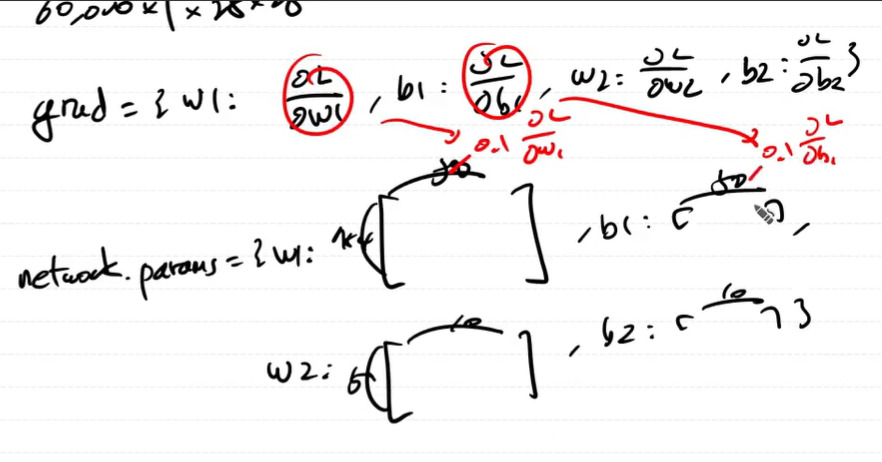`

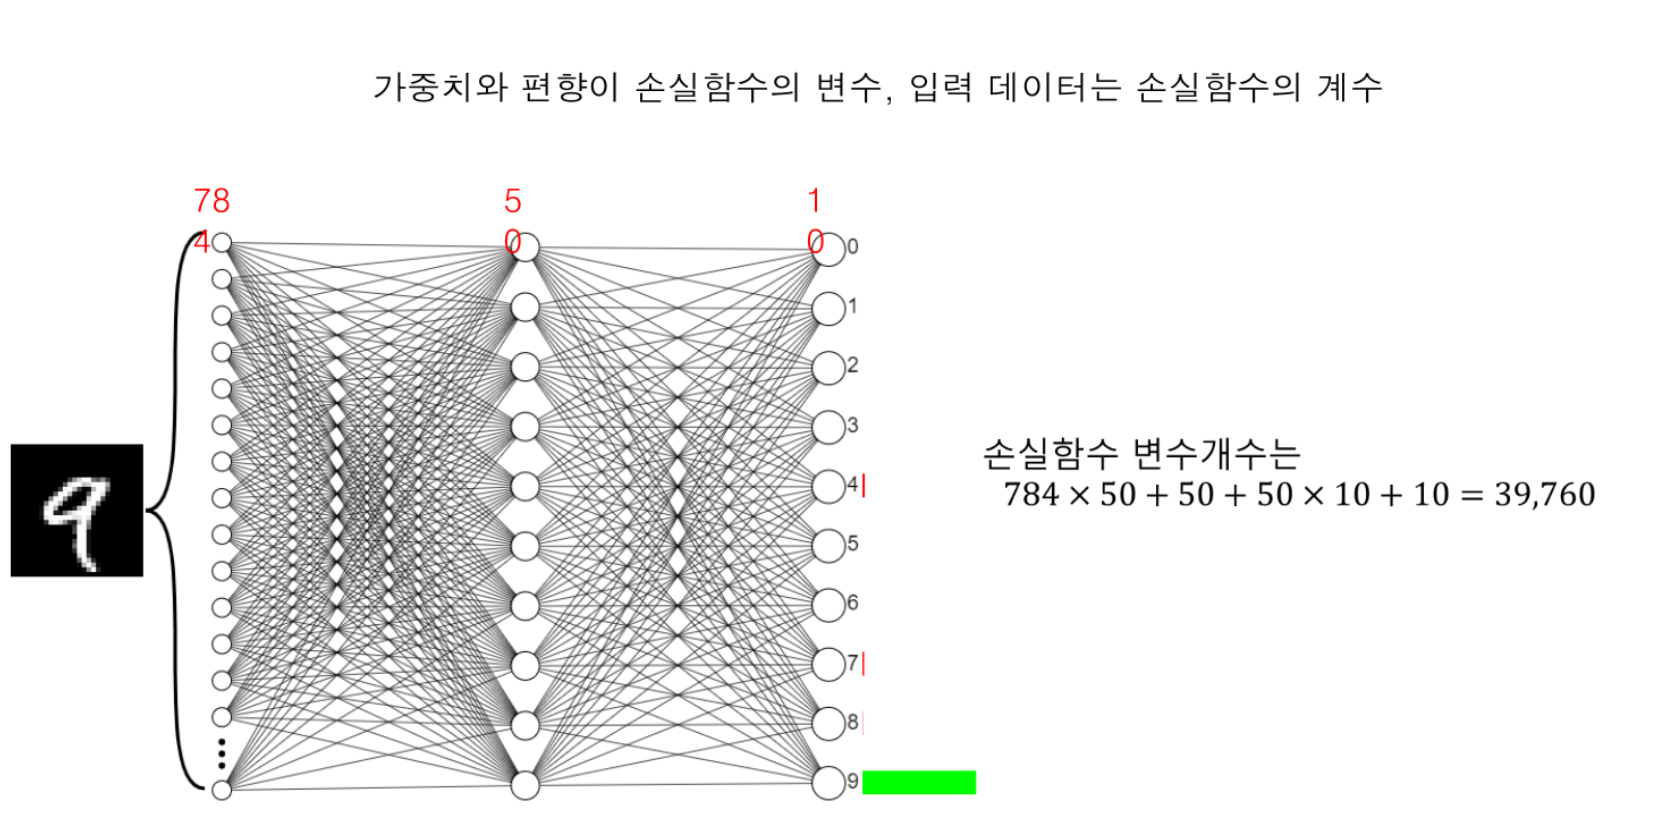

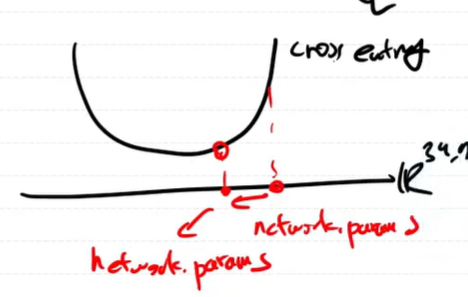

$$Loss = -\frac{1}{100} \sum_{n=1}^{100} \sum_{k=1}^{10} t_{nk} \log(y_{nk})$$

- n : 지금 보고 있는 것이 몇번째 이미지인가?
- k : 0 ~ 9 중 몇 번째 숫자에 대한 확률인가?
- $y_{nk}$: $n$번째 이미지에 대해 모델이 $k$일 확률을 예측한 값
- $t_{nk}$: $n$번째 이미지의 실제 정답지에서 $k$번 자리에 써 있는 값

train acc, test acc | 0.10441666666666667, 0.1028
train acc, test acc | 0.7936, 0.7969
train acc, test acc | 0.8753, 0.8809
train acc, test acc | 0.89785, 0.9015
train acc, test acc | 0.90785, 0.9099
train acc, test acc | 0.9147833333333333, 0.9168
train acc, test acc | 0.9203, 0.9215
train acc, test acc | 0.9254333333333333, 0.9254
train acc, test acc | 0.9291166666666667, 0.9286
train acc, test acc | 0.9321833333333334, 0.9321
train acc, test acc | 0.9347, 0.9351
train acc, test acc | 0.93745, 0.9356
train acc, test acc | 0.94025, 0.9408
train acc, test acc | 0.9421166666666667, 0.9415
train acc, test acc | 0.9443, 0.9426
train acc, test acc | 0.94565, 0.9428
train acc, test acc | 0.9476333333333333, 0.9443


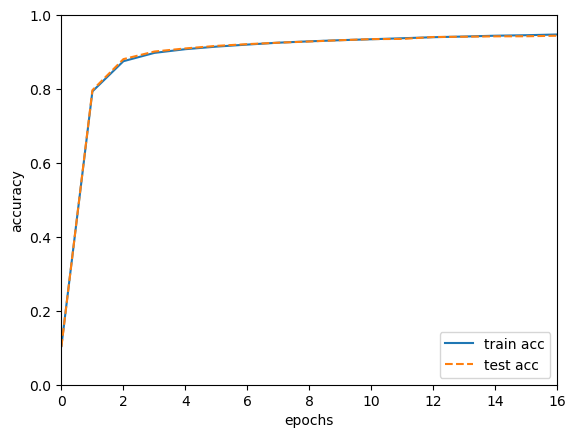

In [85]:
import numpy as np
#from dataset.mnist import load_mnist
#from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize = True, one_hot_label = True)

network = TwoLayerNet(input_size = 784, hidden_size = 50, output_size = 10)

# 하이퍼파라미터
iters_num = 10000  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
# 6만개의 train 데이터를 100개의 batch_size 로 나누겠다 -> 즉 에폭당 iter 은 600번
# 총 반복 횟수는 10,000번이고 1 에폭에 필요한 횟수는 600번이다. 즉 10,000/600 = 16.6 에폭
iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    # 6만개의 train 데이터에서 100 개를 랜덤하게 선택
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)  # 성능 개선판!

#class TwoLayerNet:
#  def __init__(self, input_size, hidden_size, output_size,
#              weight_init_std = 0.01):
#      # 가중치 초기화
#      self.params = {}
#      self.params['W1'] = weight_init_std * \
#                          np.random.randn(input_size, hidden_size)
#      self.params['b1'] = np.zeros(hidden_size)
#      self.params['W2'] = weight_init_std * \
#                          np.random.randn(hidden_size, output_size)
#      self.params['b2'] = np.zeros(output_size)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    #    def loss(self, x, t):
    #    y = self.predict(x)

    #    return cross_entropy_error(y, t)

    loss = network.loss(x_batch, t_batch)

    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
    # i(=10000)를 iter_per_epoch(=600) 으로 나누었을때 나누어 떨어질때만 실행한다.
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | "
            + str(train_acc) + ", " + str(test_acc))

# 그래프 그리기
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.xlim(0, 16)
plt.legend(loc='lower right')
plt.show()